
## Objectives

After completing this lab you will be able to:

*   Develop a various classification algorithms

In this lab exercise, you will learn a various classification machine learning algorithms. You will use the classification algorithms to build a model from the historical data of patients, and their response to different medications. Then you will use the trained decision tree to predict the class of an unknown patient, or to find a proper drug for a new patient.


<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#downloading_data">Downloading the Data</a></li>
        <li><a href="https://#pre-processing">Pre-processing</a></li>
        <li><a href="https://#setting_up_tree">Setting up the Decision Tree</a></li>
        <li><a href="https://#modeling">Modeling</a></li>
        <li><a href="https://#prediction">Prediction</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>


Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder or OneHotEncoder</b> (which ever you prefer) from <b>sklearn.preprocessing</b> </li>
    <li> <b>GausianNB</b> from <b>sklearn.naive_bayes</b> </li>
    <li> <b>metrics</b> from <b>sklearn.metrics</b> </li>

</ul>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

<div id="about_dataset">
    <h2>About the dataset</h2>
    Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
    <br>
    <br>
    Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
    <br>
    <br>
    It is a sample of multiclass classifier, and you can use the training part of the dataset
    to build a decision tree, and then use it to predict the class of an unknown patient, or to prescribe a drug to a new patient.
    <br>
    Typical features in the dataset:
     <li>Age (numeric)
     <li>Sex (categorical: M, F)
     <li>BP (categorical: HIGH, NORMAL, LOW)
     <li>Cholesterol (categorical: HIGH, NORMAL)
     <li>Na_to_K (numeric: Sodium/Potassium ratio)
     <li>Drug (target label)
</div>


<div id="downloading_data">
    <h2>Load the Data</h2>
</div>

Now, load the data using pandas dataframe:


In [2]:
drug = pd.read_csv('drug200.csv')

In [3]:
drug

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


<div id="Explore the data">
    <h3>Explore the data</h3>
    What is the size of data?
    What is the data descriptive?
</div>


In [7]:
# write your code here
# Display dataset size
print("The dataset size is: ", drug.shape)

# Display descriptive statistics
print("The dataset description is: ")
print(drug.describe())


The dataset size is:  (200, 6)
The dataset description is: 
              Age     Na_to_K
count  200.000000  200.000000
mean    44.315000   16.084485
std     16.544315    7.223956
min     15.000000    6.269000
25%     31.000000   10.445500
50%     45.000000   13.936500
75%     58.000000   19.380000
max     74.000000   38.247000


<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Using <b>my_data</b> as the Drug.csv data read by pandas, declare the following variables: <br>

<ul>
    <li> <b> X </b> as the <b> Feature Matrix </b> (data of my_data) </li>
    <li> <b> X </b> is 'Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'</li>
    <li> <b> Y </b> as the <b> response vector </b> (target) </li>
    <li> Y is 'Drug'</li>
</ul>


Remove the column containing the target name since it doesn't contain numeric values.


In [8]:
#split data into X and Y
# Split dataset into X (features) and Y (target)

X = drug[['Age', 'Sex', 'BP', 'Cholesterol']]
Y = drug['Drug']

# Display X
print(X)

# Display Y
print(Y)

     Age Sex      BP Cholesterol
0     23   F    HIGH        HIGH
1     47   M     LOW        HIGH
2     47   M     LOW        HIGH
3     28   F  NORMAL        HIGH
4     61   F     LOW        HIGH
..   ...  ..     ...         ...
195   56   F     LOW        HIGH
196   16   M     LOW        HIGH
197   52   M  NORMAL        HIGH
198   23   M  NORMAL      NORMAL
199   40   F     LOW      NORMAL

[200 rows x 4 columns]
0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


As you may figure out, some features in this dataset are categorical, such as **Sex** or **BP**. Convert the categorical variable into dummy/indicator variables.


In [17]:
#label encoder or OneHotEncoder for Sex, BP and Cholesterol
from sklearn.preprocessing import LabelEncoder

# Split data properly
X = drug[['Age', 'Sex', 'BP', 'Cholesterol']].copy()
Y = drug['Drug']

# Encode categorical variables
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()

X.loc[:, 'Sex'] = le_sex.fit_transform(X['Sex'])
X.loc[:, 'BP'] = le_bp.fit_transform(X['BP'])
X.loc[:, 'Cholesterol'] = le_chol.fit_transform(X['Cholesterol'])

# Convert to array format
X_encoded = X.values

# Print result
print(X_encoded)


[[23 0 0 0]
 [47 1 1 0]
 [47 1 1 0]
 [28 0 2 0]
 [61 0 1 0]
 [22 0 2 0]
 [49 0 2 0]
 [41 1 1 0]
 [60 1 2 0]
 [43 1 1 1]
 [47 0 1 0]
 [34 0 0 1]
 [43 1 1 0]
 [74 0 1 0]
 [50 0 2 0]
 [16 0 0 1]
 [69 1 1 1]
 [43 1 0 0]
 [23 1 1 0]
 [32 0 0 1]
 [57 1 1 1]
 [63 1 2 0]
 [47 1 1 1]
 [48 0 1 0]
 [33 0 1 0]
 [28 0 0 1]
 [31 1 0 0]
 [49 0 2 1]
 [39 0 1 1]
 [45 1 1 0]
 [18 0 2 1]
 [74 1 0 0]
 [49 1 1 1]
 [65 0 0 1]
 [53 1 2 0]
 [46 1 2 1]
 [32 1 0 1]
 [39 1 1 1]
 [39 0 2 1]
 [15 1 2 0]
 [73 0 2 0]
 [58 0 0 1]
 [50 1 2 1]
 [23 1 2 0]
 [50 0 2 1]
 [66 0 2 1]
 [37 0 0 0]
 [68 1 1 0]
 [23 1 2 0]
 [28 0 1 0]
 [58 0 0 0]
 [67 1 2 1]
 [62 1 1 1]
 [24 0 0 1]
 [68 0 0 1]
 [26 0 1 0]
 [65 1 0 1]
 [40 1 0 0]
 [60 1 2 1]
 [34 1 0 0]
 [38 0 1 1]
 [24 1 0 1]
 [67 1 1 1]
 [45 1 1 1]
 [60 0 0 0]
 [68 0 2 1]
 [29 1 0 0]
 [17 1 2 1]
 [54 1 2 0]
 [18 0 0 1]
 [70 1 0 0]
 [28 0 2 0]
 [24 0 2 0]
 [41 0 2 1]
 [31 1 0 1]
 [26 1 1 1]
 [36 0 0 0]
 [26 0 0 1]
 [19 0 0 0]
 [32 0 1 1]
 [60 1 0 0]
 [64 1 2 0]
 [32 0 1 0]
 [38

Print the target variable.


In [18]:
#print y
print(Y)

0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


<hr>

<div id="Model Setting">
    <h2>Setting up the Naive Bayes Algorithm</h2>
    We will be using <b>train/test split</b> on our algorithms </b>. Let's import <b>train_test_split</b> from <b>sklearn.model_selection</b>.
</div>


Now <b> train_test_split </b> will return 4 different parameters. We will name them:<br>
X_trainset, X_testset, Y_trainset, Y_testset <br> <br>
The <b> train_test_split </b> will need the parameters: <br>
X, y, test_size=0.3, and random_state=3. <br> <br>
The <b>X</b> and <b>y</b> are the arrays required before the split, the <b>test_size</b> represents the ratio of the testing dataset, and the <b>random_state</b> ensures that the dataset were split at random with consistent shuffle.


In [19]:
#write your code here
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_trainset, X_testset, Y_trainset, Y_testset = train_test_split(
    X_encoded, Y, test_size=0.3, random_state=3
)

# Optional: check shapes
print("X_train shape:", X_trainset.shape)
print("X_test shape:", X_testset.shape)
print("Y_train shape:", Y_trainset.shape)
print("Y_test shape:", Y_testset.shape)

X_train shape: (140, 4)
X_test shape: (60, 4)
Y_train shape: (140,)
Y_test shape: (60,)


Print the shape of X_trainset and y_trainset. Ensure that the dimensions match the prior splitting request.


In [20]:
print('Shape of X training set {}'.format(X_trainset.shape),'&',' Size of Y training set {}'.format(Y_trainset.shape))


Shape of X training set (140, 4) &  Size of Y training set (140,)



Print the shape of X_testset and y_testset.


In [21]:
# your code
# Print shape of test sets
print("X_testset shape:", X_testset.shape)
print("Y_testset shape:", Y_testset.shape)


X_testset shape: (60, 4)
Y_testset shape: (60,)


<hr>

<div id="modeling">
    <h2>Modeling</h2>
    Lets create an instance of the <b>Naive Bayes</b>.

</div>


In [22]:
# Create a Naive Bayes classifier and name it as Model_NB1

Model_NB1 = GaussianNB()

Next, we will fit the data with the training feature matrix <b> X_trainset </b> and training  response vector <b> y_trainset </b>


In [23]:
# Train the classifier with X_trainset and Y_trainset

Model_NB1.fit(X_trainset, Y_trainset)

GaussianNB()

<hr>

<div id="prediction">
    <h2>Prediction</h2>
    Let's make some <b>predictions</b> on the testing dataset and store it into a variable called <b>predNB1</b>.
</div>


In [24]:
#make prediction for Model_NB1 (Naive Bayes)

predNB1 = Model_NB1.predict(X_testset)

You can print out <b>predNB1</b> and <b>y_testset</b> if you want to visually compare the predictions to the actual values.





In [25]:
#Compare the predicted Y for Model_NB1 vs Actual Y Test

print(predNB1)
print(Y_testset)

['drugX' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC' 'drugA' 'drugA' 'drugB'
 'drugA' 'drugX' 'drugA' 'drugA' 'drugB' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugB' 'drugX' 'drugX' 'drugB' 'drugC' 'drugX' 'drugY' 'drugB' 'drugY'
 'drugX' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugX' 'drugX' 'drugC'
 'drugC' 'drugX' 'drugX' 'drugX' 'drugA' 'drugA' 'drugC' 'drugA' 'drugA'
 'drugB' 'drugX' 'drugX' 'drugC' 'drugY' 'drugB' 'drugX' 'drugX' 'drugY'
 'drugX' 'drugB' 'drugA' 'drugX' 'drugX' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's check the accuracy of our model.
</div>


In [26]:
#check the confusion matrix

conf = confusion_matrix(Y_testset, predNB1, )
print(conf)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 16  5]
 [ 4  4  3  9  2]]


In [27]:
#check the accuracy

acc = accuracy_score(Y_testset, predNB1)
print(acc)

0.5833333333333334


In [28]:
#check the classification report

report = classification_report(Y_testset, predNB1)
print(report)

              precision    recall  f1-score   support

       drugA       0.64      1.00      0.78         7
       drugB       0.56      1.00      0.71         5
       drugC       0.62      1.00      0.77         5
       drugX       0.64      0.76      0.70        21
       drugY       0.29      0.09      0.14        22

    accuracy                           0.58        60
   macro avg       0.55      0.77      0.62        60
weighted avg       0.50      0.58      0.51        60



**Accuracy classification score** computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

In multilabel classification, the function returns the subset accuracy. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.


<hr>

<div id="visualization">
    <h2>Visualization</h2>

Let's visualize Confusion Matrix using heatmap.

</div>


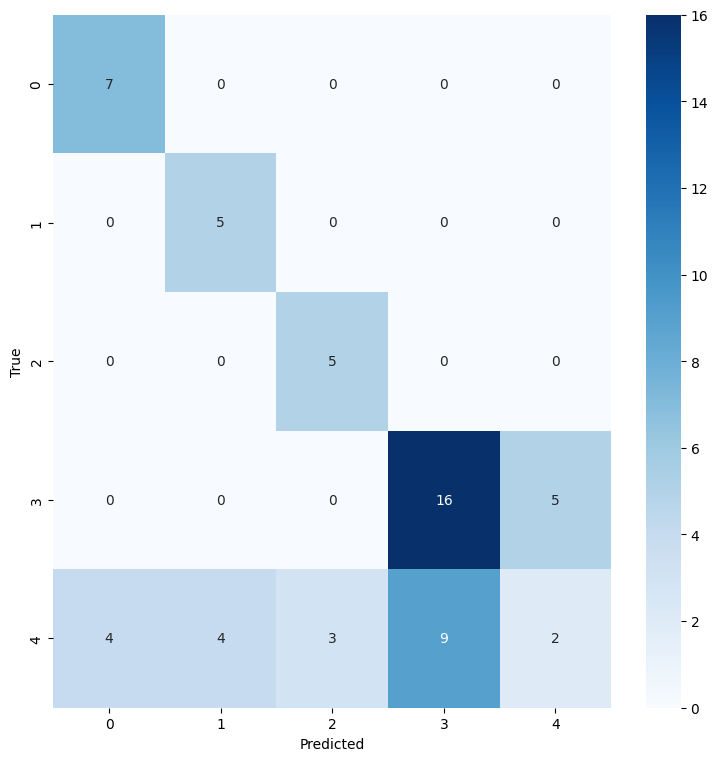

In [29]:
#heatmap for confusion matrix

plt.figure(figsize=(9,9))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



# Another variant of Naive Bayes

In [32]:
# try to set the parameter such as var_smoothing or alpha in the models
# let try using another variant of naive bayes such as Multinomial and Bernoulli
# split the data using cross validation technique
# compare the performance of each models

from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
import numpy as np

# ----------------------------
# Multinomial Naive Bayes
# ----------------------------
mnb = MultinomialNB(alpha=1.0)  # you can change alpha

mnb_scores = cross_val_score(
    mnb, X_encoded, Y, cv=5
)

print("Multinomial NB Accuracy Scores:", mnb_scores)
print("Mean Accuracy:", np.mean(mnb_scores))


# ----------------------------
# Bernoulli Naive Bayes
# ----------------------------
bnb = BernoulliNB(alpha=1.0)

bnb_scores = cross_val_score(
    bnb, X_encoded, Y, cv=5
)

print("\nBernoulli NB Accuracy Scores:", bnb_scores)
print("Mean Accuracy:", np.mean(bnb_scores))

Multinomial NB Accuracy Scores: [0.6   0.5   0.5   0.425 0.5  ]
Mean Accuracy: 0.505

Bernoulli NB Accuracy Scores: [0.55  0.475 0.55  0.525 0.5  ]
Mean Accuracy: 0.52


In [36]:
#make prediction for Model_NB2 (Multinomial Naive Bayes)
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.naive_bayes import MultinomialNB

# Train model
Model_NB2 = MultinomialNB(alpha=1.0)
Model_NB2.fit(X_trainset, Y_trainset)

# Prediction
y_pred = Model_NB2.predict(X_testset)

# Confusion matrix
cm = confusion_matrix(Y_testset, y_pred)
print(cm)

# Accuracy
acc = accuracy_score(Y_testset, y_pred)
print(acc)

[[ 0  0  0  0  7]
 [ 0  0  0  0  5]
 [ 0  0  0  0  5]
 [ 0  0  0  5 16]
 [ 0  0  0  2 20]]
0.4166666666666667


In [37]:
#make prediction for Model_NB3 (Categorical Naive Bayes)
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score

# Train model
Model_NB3 = CategoricalNB()
Model_NB3.fit(X_trainset, Y_trainset)

# Prediction
y_pred3 = Model_NB3.predict(X_testset)

# Confusion matrix
cm3 = confusion_matrix(Y_testset, y_pred3)
print(cm3)

# Accuracy
acc3 = accuracy_score(Y_testset, y_pred3)
print(acc3)

[[ 0  0  0  0  7]
 [ 0  1  0  0  4]
 [ 0  0  1  1  3]
 [ 0  0  0  9 12]
 [ 1  0  1  6 14]]
0.4166666666666667


In [39]:
#make prediction for Model_NB5 (Gaussian Naive Bayes) with alpha
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# Train model
Model_NB5 = GaussianNB(var_smoothing=1e-9)
Model_NB5.fit(X_trainset, Y_trainset)

# Prediction
y_pred5 = Model_NB5.predict(X_testset)

# Confusion matrix
cm5 = confusion_matrix(Y_testset, y_pred5)
print(cm5)

# Accuracy
acc5 = accuracy_score(Y_testset, y_pred5)
print(acc5)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 16  5]
 [ 4  4  3  9  2]]
0.5833333333333334


# Logistic Regression

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_trainset)
X_test_scaled = scaler.transform(X_testset)

# Train model
Model_LR = LogisticRegression(max_iter=1000)
Model_LR.fit(X_train_scaled, Y_trainset)

# Predict
y_pred_lr = Model_LR.predict(X_test_scaled)

# Evaluation
print(confusion_matrix(Y_testset, y_pred_lr))
print(accuracy_score(Y_testset, y_pred_lr))

[[ 1  0  0  0  6]
 [ 0  2  0  0  3]
 [ 0  0  0  0  5]
 [ 0  0  0  9 12]
 [ 1  4  0  5 12]]
0.4


Another variant of Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

Model_LR2 = LogisticRegression(
    solver='liblinear',
    max_iter=1000
)

Model_LR2.fit(X_trainset, Y_trainset)

y_pred_lr2 = Model_LR2.predict(X_testset)

print(confusion_matrix(Y_testset, y_pred_lr2))
print(accuracy_score(Y_testset, y_pred_lr2))


Model_LR3 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

Model_LR3.fit(X_trainset, Y_trainset)

y_pred_lr3 = Model_LR3.predict(X_testset)

print(confusion_matrix(Y_testset, y_pred_lr3))
print(accuracy_score(Y_testset, y_pred_lr3))

Model_LR4 = LogisticRegression(
    C=0.5,
    max_iter=1000
)

Model_LR4.fit(X_trainset, Y_trainset)

y_pred_lr4 = Model_LR4.predict(X_testset)

print(confusion_matrix(Y_testset, y_pred_lr4))
print(accuracy_score(Y_testset, y_pred_lr4))

[[ 0  0  0  0  7]
 [ 0  2  0  0  3]
 [ 0  0  0  0  5]
 [ 0  0  0 13  8]
 [ 0  0  0  6 16]]
0.5166666666666667
[[ 0  0  0  0  7]
 [ 0  2  0  0  3]
 [ 0  0  0  0  5]
 [ 0  0  0 11 10]
 [ 0  3  0  5 14]]
0.45
[[ 0  0  0  0  7]
 [ 0  2  0  0  3]
 [ 0  0  0  0  5]
 [ 0  0  0 13  8]
 [ 0  3  0  5 14]]
0.48333333333333334


# Decison Tree

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Create model
Model_DT = DecisionTreeClassifier(random_state=3)

# Train model
Model_DT.fit(X_trainset, Y_trainset)

# Prediction
y_pred_dt = Model_DT.predict(X_testset)

# Confusion matrix
print(confusion_matrix(Y_testset, y_pred_dt))

# Accuracy
print(accuracy_score(Y_testset, y_pred_dt))

[[ 1  0  0  0  6]
 [ 0  2  0  0  3]
 [ 0  0  2  0  3]
 [ 0  0  0 10 11]
 [ 1  5  1  6  9]]
0.4


Another variant of Decision Tree

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

Model_DT2 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=3
)

Model_DT2.fit(X_trainset, Y_trainset)

y_pred_dt2 = Model_DT2.predict(X_testset)

print(confusion_matrix(Y_testset, y_pred_dt2))
print(accuracy_score(Y_testset, y_pred_dt2))

Model_DT3 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=3
)

Model_DT3.fit(X_trainset, Y_trainset)

y_pred_dt3 = Model_DT3.predict(X_testset)

print(confusion_matrix(Y_testset, y_pred_dt3))
print(accuracy_score(Y_testset, y_pred_dt3))

Model_DT4 = DecisionTreeClassifier(
    min_samples_leaf=5,
    random_state=3
)

Model_DT4.fit(X_trainset, Y_trainset)

y_pred_dt4 = Model_DT4.predict(X_testset)

print(confusion_matrix(Y_testset, y_pred_dt4))
print(accuracy_score(Y_testset, y_pred_dt4))

[[ 1  0  0  0  6]
 [ 0  2  0  0  3]
 [ 0  0  2  0  3]
 [ 0  0  0 11 10]
 [ 1  5  1  7  8]]
0.4
[[ 0  0  0  0  7]
 [ 0  5  0  0  0]
 [ 0  0  3  0  2]
 [ 0  0  0  9 12]
 [ 0  4  2  2 14]]
0.5166666666666667
[[ 0  0  0  0  7]
 [ 0  2  0  0  3]
 [ 0  0  3  0  2]
 [ 0  0  0 14  7]
 [ 0  4  2  6 10]]
0.48333333333333334


# Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Create model
Model_RF = RandomForestClassifier(
    n_estimators=100,
    random_state=3
)

# Train model
Model_RF.fit(X_trainset, Y_trainset)

# Prediction
y_pred_rf = Model_RF.predict(X_testset)

# Confusion matrix
print(confusion_matrix(Y_testset, y_pred_rf))

# Accuracy
print(accuracy_score(Y_testset, y_pred_rf))

[[ 1  0  0  0  6]
 [ 0  3  0  0  2]
 [ 0  0  2  0  3]
 [ 0  0  0 14  7]
 [ 1  3  1  7 10]]
0.5


# KNN

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Create model
Model_KNN = KNeighborsClassifier(n_neighbors=5)

# Train model
Model_KNN.fit(X_trainset, Y_trainset)

# Prediction
y_pred_knn = Model_KNN.predict(X_testset)

# Confusion matrix
print(confusion_matrix(Y_testset, y_pred_knn))

# Accuracy
print(accuracy_score(Y_testset, y_pred_knn))

[[ 0  0  0  2  5]
 [ 0  2  0  0  3]
 [ 1  1  0  1  2]
 [ 1  1  2  7 10]
 [ 3  0  2  5 12]]
0.35


# Support Vector Machine (Classification)

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

# Create model
Model_SVM = SVC(kernel='linear', random_state=3)

# Train model
Model_SVM.fit(X_trainset, Y_trainset)

# Prediction
y_pred_svm = Model_SVM.predict(X_testset)

# Confusion matrix
print(confusion_matrix(Y_testset, y_pred_svm))

# Accuracy
print(accuracy_score(Y_testset, y_pred_svm))

[[ 0  0  0  0  7]
 [ 0  2  0  0  3]
 [ 0  0  0  0  5]
 [ 0  0  0 13  8]
 [ 0  4  0  7 11]]
0.43333333333333335


Another variant of SVC

In [50]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

Model_SVM4 = SVC(
    kernel='linear',
    C=0.5,
    random_state=3
)

Model_SVM4.fit(X_trainset, Y_trainset)

y_pred_svm4 = Model_SVM4.predict(X_testset)

print(confusion_matrix(Y_testset, y_pred_svm4))
print(accuracy_score(Y_testset, y_pred_svm4))

[[ 0  0  0  0  7]
 [ 0  2  0  0  3]
 [ 0  0  0  0  5]
 [ 0  0  0 15  6]
 [ 0  4  0  8 10]]
0.45


Explain your findings

In [51]:
print("""
Findings:

Based on all models tested (Naive Bayes variants, Logistic Regression, Decision Tree, Random Forest, KNN, and SVM),
the performance varies depending on the algorithm and preprocessing steps.

Random Forest and SVM generally give better performance because they handle complex patterns well.

KNN and Logistic Regression are sensitive to feature scaling, and their performance improves after normalization.

Decision Tree may overfit if not properly tuned, while Naive Bayes is fast but less accurate due to strong assumptions about data independence.

Overall, Random Forest or SVM (RBF kernel) are the most suitable models for this dataset.

Conclusion:
There is no single best algorithm. Performance depends on data preprocessing, parameter tuning, and model suitability.
""")


Findings:

Based on all models tested (Naive Bayes variants, Logistic Regression, Decision Tree, Random Forest, KNN, and SVM), 
the performance varies depending on the algorithm and preprocessing steps.

Random Forest and SVM generally give better performance because they handle complex patterns well.

KNN and Logistic Regression are sensitive to feature scaling, and their performance improves after normalization.

Decision Tree may overfit if not properly tuned, while Naive Bayes is fast but less accurate due to strong assumptions about data independence.

Overall, Random Forest or SVM (RBF kernel) are the most suitable models for this dataset.

Conclusion:
There is no single best algorithm. Performance depends on data preprocessing, parameter tuning, and model suitability.

